Capstone project:

Dataset: Telco Customer Churn (Kaggle) — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Target variable:MonthlyCharges

Model: Linear Regression (scikit-learn)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#loading the dataset
df = pd.read_csv("C:/Users/HP/Desktop/capstone project/Telco-Customer-Churn.csv")

Understanding the Dataset

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
4696,9128-CPXKI,Female,0,No,No,59,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Electronic check,95.80,5655.45,No
2961,6898-MDLZW,Male,0,No,No,12,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,53.75,648.65,No
6308,5442-BHQNG,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,70.35,139.25,No
5710,6297-NOOPG,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,110.50,7752.05,No


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for column in df.select_dtypes(include='object').columns:
    print(f'\n{column}')
    print(df[column].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']


In [11]:
df['TotalCharges'].dtype

dtype('O')

In [12]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [13]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [14]:
#Handling missing value for total charges
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [15]:
df['TotalCharges'].isnull().sum()

np.int64(0)

Understanding the Target Variable: MonthlyCharges

In [16]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Exploratory Data Analysis

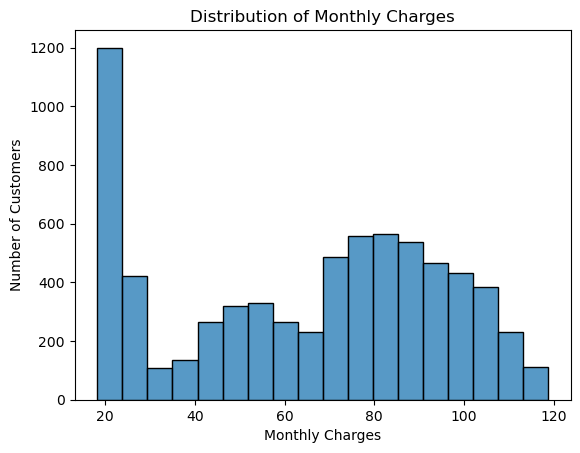

In [17]:
#What is the distribution of MonthlyCharges?
sns.histplot(
    df['MonthlyCharges']
)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()


The histogram plot shows two humps: a large group of customers around $20 paying almost the same low amount phone only, no internet and a wider lower hump between about 65-100 dollars for customers with internet plus add-ons, so their prices spread out more. The monthlyCharges is not one smooth range it is really two different customer populations.

In [18]:
#Which customer services are associated with higher monthly charges?
service_columns = [
    'PhoneService',
    'OnlineSecurity',
    'TechSupport',
    'OnlineBackup',
    'DeviceProtection',
    'MultipleLines',
    'StreamingTV',
    'StreamingMovies'
]
for col in service_columns:
    print('f\n{col}')
    print(
    df.groupby(col)['MonthlyCharges']
    .mean()
    .sort_values(ascending=False)
    )

f
{col}
PhoneService
Yes    67.199041
No     42.028592
Name: MonthlyCharges, dtype: float64
f
{col}
OnlineSecurity
Yes                    78.838732
No                     75.693067
No internet service    21.079194
Name: MonthlyCharges, dtype: float64
f
{col}
TechSupport
Yes                    80.680137
No                     74.586683
No internet service    21.079194
Name: MonthlyCharges, dtype: float64
f
{col}
OnlineBackup
Yes                    83.081597
No                     71.938002
No internet service    21.079194
Name: MonthlyCharges, dtype: float64
f
{col}
DeviceProtection
Yes                    84.822254
No                     70.601050
No internet service    21.079194
Name: MonthlyCharges, dtype: float64
f
{col}
MultipleLines
Yes                 82.036974
No                  54.195059
No phone service    42.028592
Name: MonthlyCharges, dtype: float64
f
{col}
StreamingTV
Yes                    88.736738
No                     65.387687
No internet service    21.079194
Name: M

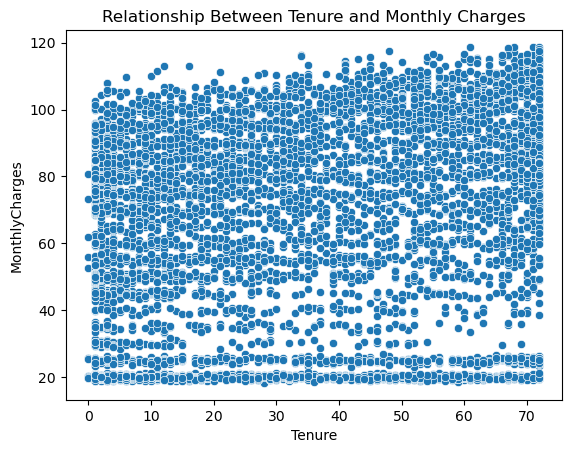

In [19]:
#How does tenure relate to MonthlyCharges?
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges'
)
plt.title('Relationship Between Tenure and Monthly Charges')
plt.xlabel('Tenure')
plt.ylabel('MonthlyCharges')
plt.show()

The dots are spread evenly across the whole plot, with no clear upward or downward slope. This indicates that been a customer for long barely affects what you pay, tenure and price are not strongly related.

In [20]:
df[['tenure', 'MonthlyCharges']].corr()

,tenure,MonthlyCharges
tenure,1.0000,0.2479
MonthlyCharges,0.2479,1.0000


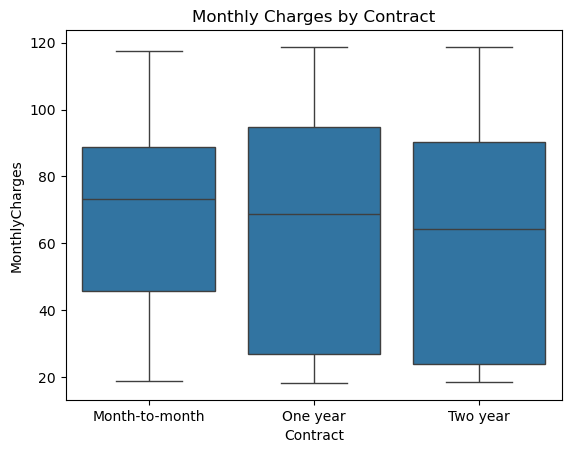

In [21]:
#Do contract types differ in their average monthly charges?
sns.boxplot(
    x='Contract', y='MonthlyCharges', data=df
)
plt.title('Monthly Charges by Contract')
plt.xlabel('Contract')
plt.ylabel('MonthlyCharges')
plt.show()

The boxplot shows three boxes, the box is the middle 50% of customers, the line inside is the median, the whiskers show the range. One year and two year boxes sit a bit higher than Month to month. This indicates longer contract customers tend to pay slightly more on average likely because they have bundled in more services, not because the contract itself costs more.

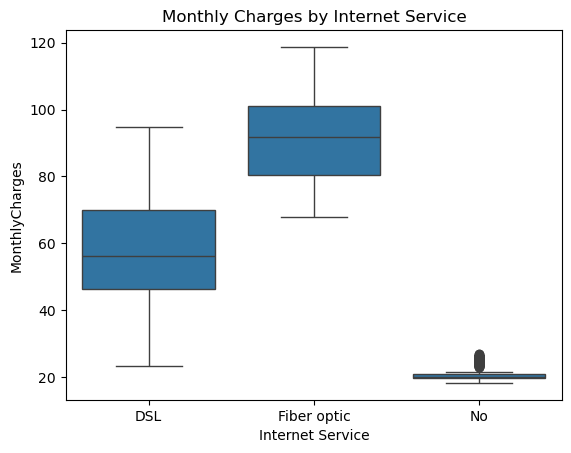

In [22]:
#How do internet service types compare in terms of monthly charges?
sns.boxplot(
    data=df, x='InternetService', y='MonthlyCharges'
)
plt.title('Monthly Charges by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('MonthlyCharges')
plt.show()

This boxplot shows that what internet service a customer has is the single biggest thing seperating high payers from low payers.

In [23]:
#which categorical variables show the strongest differences in Monthly Charges?
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if col != 'customerID':
        summary = df.groupby(col)['MonthlyCharges'].mean()
        difference = summary.max() - summary.min()
        print(
            f'{col}:'
            f'Difference = {difference:.2f}'
        )

gender:Difference = 0.88
Partner:Difference = 5.83
Dependents:Difference = 7.48
PhoneService:Difference = 25.17
MultipleLines:Difference = 40.01
InternetService:Difference = 70.42
OnlineSecurity:Difference = 57.76
OnlineBackup:Difference = 62.00
DeviceProtection:Difference = 63.74
TechSupport:Difference = 59.60
StreamingTV:Difference = 67.66
StreamingMovies:Difference = 67.40
Contract:Difference = 5.63
PaperlessBilling:Difference = 21.56
PaymentMethod:Difference = 32.34
Churn:Difference = 13.18


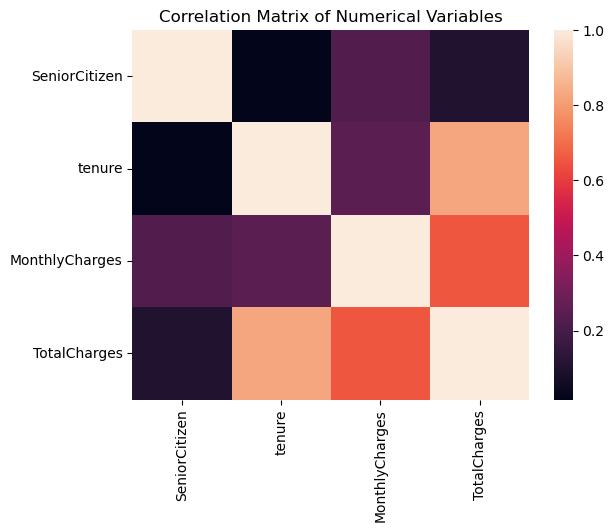

In [24]:
#Are there meaningful correlations among the numerical variables?
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()
sns.heatmap(
    correlation_matrix
)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Each square shows how strongly two numeric variables move together, from -1 to 1 (color scale on the side). tenure and totalcharges show up as strongly correlated, monthlycharges and tenure/seniorcitizen are much weaker

Building, Training, and Testing the Linear Regression Model

In [25]:
#Define the target
y = df['MonthlyCharges']

In [29]:
#Define the Predictors
predictors_col = [
    'tenure',
    'SeniorCitizen',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]
X = df[predictors_col]
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (7043, 14)
y shape: (7043,)


In [27]:
#Encoding Categorical Variables
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns
print('Num:', list(numerical_cols))
print('Cat:', list(categorical_cols))

Num: ['tenure', 'SeniorCitizen']
Cat: ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
         ]
)

In [30]:
np.random.seed(42)

In [31]:
#1.Building and Training the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [33]:
#2.Training the model
from sklearn.pipeline import Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('regressor', LinearRegression())
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['tenure', 'SeniorCitizen'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [34]:
#Testing the model
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 24.95721568  24.9784471   19.93776462  74.97641086  49.99537796
  89.90161413  75.06427866  70.08483983 104.94965994  19.98845613]


In [36]:
#Evaluating the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MSE: 1.10456255390916
MAE: 0.78887940963513
RMSE: 1.0509817095978216
R2: 0.9987799939099656


MSE: measures the average squared difference btwn actual and predicted charges. The MSE is 1.105 which is very low, means predictions are close to actual values.
MAE: is the average absolute difference between actual and predicted monthlycharges in the the same unit as the target ($). A 0.79 dollar means the predictions are off by a very small error.
RMSE: is the square root of MSE, bringing the error back into dollar units like MAE, but it weighs large errors more heavily.The RMSE of 1.05 is close to the MAE.
R2: shows the porportion of variance in MonthlyCharges that the model explains, from 0 to 1. the 0.998 means the model explains about 99.9% of the variation in charges.

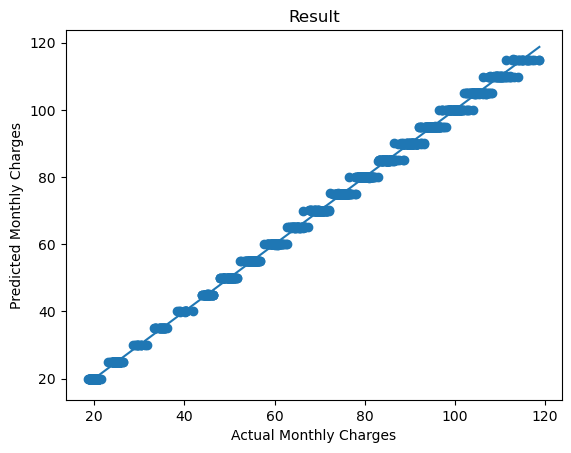

In [37]:
#Visualizing the Result
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.title('Result')
plt.show()

This shows that the model predictions are extremely close to the real values.

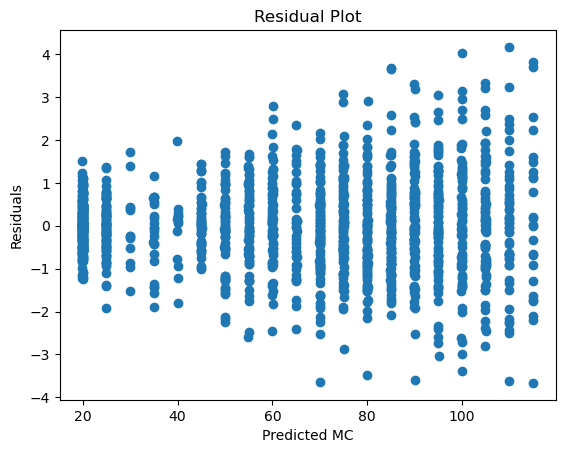

In [38]:
#Visualizing Residual
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted MC')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

The errors are small and consistent across the whole price range.

In [42]:
#Coefficient
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

                                     Feature  Coefficient
            cat__InternetService_Fiber optic    15.213352
                    cat__InternetService_DSL    -9.735419
                        cat__StreamingTV_Yes     7.732344
                    cat__StreamingMovies_Yes     7.714555
                       cat__PhoneService_Yes     6.441092
         cat__MultipleLines_No phone service    -6.441092
                        cat__PhoneService_No    -6.441092
                      cat__MultipleLines_Yes     5.730025
   cat__DeviceProtection_No internet service    -5.477933
        cat__StreamingTV_No internet service    -5.477933
    cat__StreamingMovies_No internet service    -5.477933
                     cat__InternetService_No    -5.477933
        cat__TechSupport_No internet service    -5.477933
       cat__OnlineBackup_No internet service    -5.477933
     cat__OnlineSecurity_No internet service    -5.477933
                     cat__OnlineSecurity_Yes     5.266118
              

The above lists each variable and how much it pushes the prediction up or down 